In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import argparse
from nnfabrik.builder import get_data, get_trainer

from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from modified_neuralpredictors.wandb_trainer import standard_trainer

random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 128,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

model_config = {
    'hidden_channels': 64, # original sensorium was 64ch
    'depth_separable': False,
    'use_avg_reg': False,
    'laplace_padding': None,
    'momentum': 0.75,
    'final_nonlinearity': True,
    'nonlinearity_type': 'AdaptiveELU',
    'pad_input': False,
    'stack': -1,
    'layers': 4,
    'input_kern': 11, #  original sensorium was 'input_kern': 9,
    'gamma_input': 6.3831, # this should not influence the performance based on previous experience
    
    'feature_reg_weight': 3, # this is the one I actually would like to tune!
    
    'hidden_kern': 7,
    'grid_mean_predictor': {
        'type': 'cortex',
        'input_dimensions': 2,
        'hidden_layers': 1,
        'hidden_features': 30,
        'final_tanh': True
    },
    
    'init_sigma': 0.1,
    'init_mu_range': 0.3,
    'gauss_type': 'full',
    'shifter': True,
    'batch_norm_scale': [True, True, True, False],
    'core_bias': [True, True, True, False],
    'regularizer_type': "adaptive_log_norm",
    'gamma_sigma' : 0.25,
}

model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
model.to(device);
model.train()

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


FiringRateEncoder(
  (core): Stacked2dCore(
    (_input_weights_regularizer): LaplaceL2norm(
      (laplace): Laplace()
    )
    (features): Sequential(
      (layer0): Sequential(
        (conv): Conv2d(4, 64, kernel_size=(11, 11), stride=(1, 1), bias=False)
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer1): Sequential(
        (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer2): Sequential(
        (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
        (norm): BatchNorm2d(64, eps=1e-05, momentum=0.75, affine=True, track_running_stats=True)
        (nonlin): AdaptiveELU()
      )
      (layer3): Sequential(
        (conv): Conv2d(64, 64, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3)

In [2]:
base_reg3_path = 'runs/newbase/dim64_seed0/model_weights.pth'
base_reg1_path = 'runs/newbase/base_regw1_seed0/model_weights.pth'
seeds = [3, 10, 17, 29, 31, 43]
read_reg3_paths = [
    'runs/readout_consistency/baseseed0_seed3/model_weights.pth',
    'runs/readout_consistency/baseseed0_seed10/model_weights.pth',
    'runs/readout_consistency/baseseed0_seed17/model_weights.pth',
    'runs/readout_consistency/baseseed0_seed29/model_weights.pth',
    'runs/readout_consistency/baseseed0_seed31/model_weights.pth',
    'runs/readout_consistency/baseseed0_seed43/model_weights.pth',
]

read_reg1_paths = [
    'runs/readout_consistency/basereg1_seed3/model_weights.pth',
    'runs/readout_consistency/basereg1_seed10/model_weights.pth',
    'runs/readout_consistency/basereg1_seed17/model_weights.pth',
    'runs/readout_consistency/basereg1_seed29/model_weights.pth',
    'runs/readout_consistency/basereg1_seed31/model_weights.pth',
    'runs/readout_consistency/basereg1_seed43/model_weights.pth',
]

In [31]:
model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
model.load_state_dict(torch.load(read_reg1_paths[5], map_location=device))
model.to(device);
model.train();

num_batches = 3

grids = []
shifts = []

for key in data_keys:
    grid = model.readout[key].sample_grid(1, sample=False).detach().cpu()
    grid_mean = grid.squeeze().mean(0, keepdim=True)
    grid_centered = grid - grid_mean
    
    batch_num = 0

    shifts_batches = []
    for batch in dataloaders['validation'][key]:
        batch_num += 1
        img, _, _, pupil = batch
        shift = model.shifter[key](pupil, None).detach().cpu()
        shift = shift + grid_mean
        shifts_batches.append(shift)

        if batch_num == num_batches:
            break
        

    grids.append(grid_centered)
    shifts.append(torch.cat(shifts_batches))

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


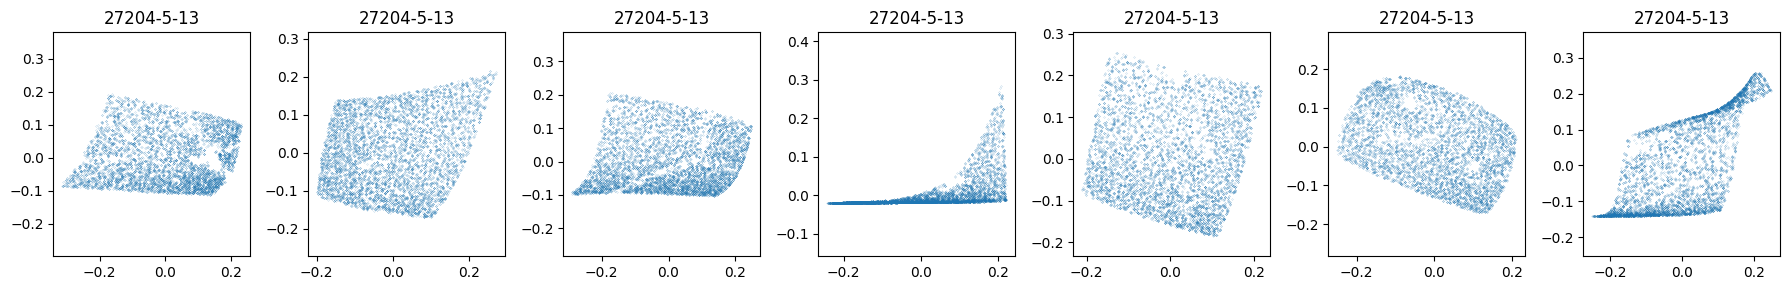

In [19]:
fig, axs = plt.subplots(1, 7, figsize=(18, 3))

for ax, grid in zip(axs, grids):
    ax.scatter(grid.squeeze()[:, 0], grid.squeeze()[:, 1], s=0.01, label=key)
    ax.axis('equal')
    ax.set_title(key)
    # ax.set_xticks([])
    # ax.set_yticks([])
    # ax.spines.clear()

plt.tight_layout()
plt.show()

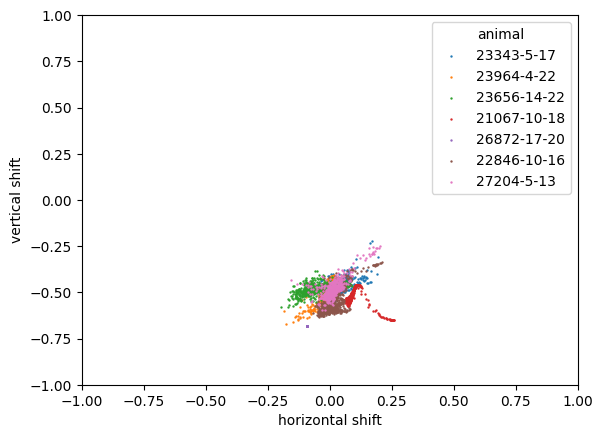

In [20]:
for shift, key in zip(shifts, data_keys):
    plt.scatter(shift[:, 0], shift[:, 1], s=.5, label=key)

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel('horizontal shift')
plt.ylabel('vertical shift')
plt.legend(title='animal')
plt.show()

# nicer plots

In [82]:
num_batches = 3

rfs = []

for path in read_reg3_paths:
    model = stacked_core_full_gauss_readout(dataloaders, random_seed, **model_config)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device);
    model.train();

    grids = []
    shifts = []

    for key in data_keys:
        grid = model.readout[key].sample_grid(1, sample=False).detach().cpu()
        grid_mean = grid.squeeze().mean(0, keepdim=True)
        grid_centered = grid - grid_mean
        
        batch_num = 0

        shifts_batches = []
        for batch in dataloaders['validation'][key]:
            batch_num += 1
            img, _, _, pupil = batch
            shift = model.shifter[key](pupil, None).detach().cpu()
            shift = shift + grid_mean
            shifts_batches.append(shift)

            if batch_num == num_batches:
                break
            

        grids.append(grid_centered)
        shifts.append(torch.cat(shifts_batches))
    
    grid = grids[0]
    shift = shifts[0]

    model_rfs = []
    for grid, shift in zip(grids, shifts):
        model_rfs.append(grid.squeeze(0) + shift.unsqueeze(0))
    rfs.append(model_rfs)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


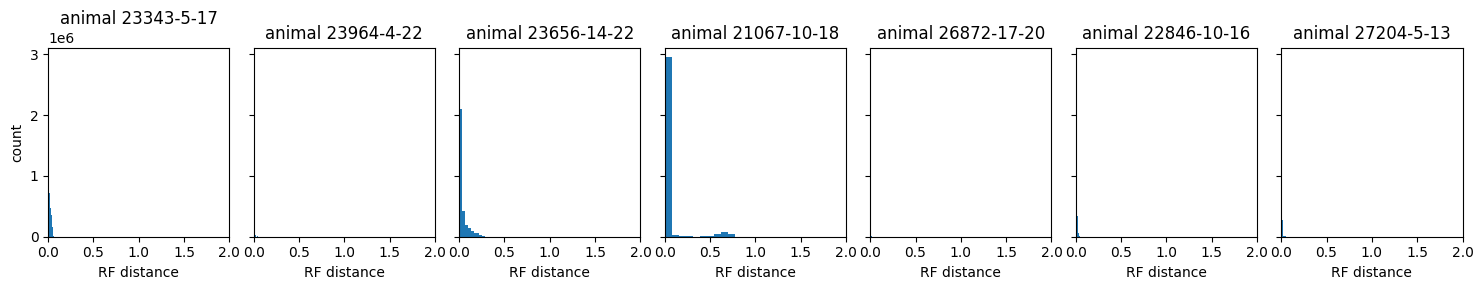

In [91]:
fig, axs = plt.subplots(1, 7, figsize=(15, 3), sharey=True)
ylabeled = False
for ax, rf0, rf1, label in zip(axs, rfs[4], rfs[1], data_keys):
    dist = (rf0 - rf1).flatten(0, 1).pow(2).sum(1).sqrt()
    ax.hist(dist)
    ax.set_title(f'animal {label}')
    if not ylabeled:
        ax.set_ylabel('count')
    ax.set_xlabel('RF distance')
    ax.set_xlim(0, 2)

    ylabeled = True

plt.tight_layout()